In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
from mlflow import MlflowClient

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [0]:
!pip install lightgbm

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Dataset path
DATA_PATH = "demand_forecasting.csv"

# MLflow experiment
EXPERIMENT_NAME = "/Shared/demand-forecasting"

# Name of the MLflow run we want to evaluate
RUN_NAME = "lightgbm_demand_forecasting"

TARGET = "Demand"

GROUP_COLS = ["Store ID","Product ID"]

In [0]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (76000, 16)


Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [0]:
df["Date"] = pd.to_datetime(df["Date"])

df = (df.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True))

print("Date range:")
print(df["Date"].min(), "to", df["Date"].max())

Date range:
2022-01-01 00:00:00 to 2024-01-30 00:00:00


In [0]:
df["day_of_week"] = df["Date"].dt.dayofweek
df["day_of_month"] = df["Date"].dt.day
df["week_of_year"] = df["Date"].dt.isocalendar().week.astype(int)
df["month"] = df["Date"].dt.month
df["quarter"] = df["Date"].dt.quarter
df["year"] = df["Date"].dt.year
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

display(
    df[
        [
            "Date",
            "day_of_week",
            "day_of_month",
            "week_of_year",
            "month",
            "quarter",
            "year",
            "is_weekend"
        ]
    ].head()
)

Date,day_of_week,day_of_month,week_of_year,month,quarter,year,is_weekend
2022-01-01T00:00:00.000Z,5,1,52,1,1,2022,1
2022-01-02T00:00:00.000Z,6,2,52,1,1,2022,1
2022-01-03T00:00:00.000Z,0,3,1,1,1,2022,0
2022-01-04T00:00:00.000Z,1,4,1,1,1,2022,0
2022-01-05T00:00:00.000Z,2,5,1,1,1,2022,0


In [0]:
LAG_FEATURES = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28"
]

for lag in [1, 7, 14, 28]:

    df[f"lag_{lag}"] = (
        df.groupby(GROUP_COLS)["Demand"]
          .shift(lag)
    )

display(
    df[
        GROUP_COLS +
        ["Date", "Demand"] +
        LAG_FEATURES
    ].head(35)
)

Store ID,Product ID,Date,Demand,lag_1,lag_7,lag_14,lag_28
S001,P0001,2022-01-01T00:00:00.000Z,115,null,null,null,null
S001,P0001,2022-01-02T00:00:00.000Z,84,115.0,null,null,null
S001,P0001,2022-01-03T00:00:00.000Z,132,84.0,null,null,null
S001,P0001,2022-01-04T00:00:00.000Z,67,132.0,null,null,null
S001,P0001,2022-01-05T00:00:00.000Z,110,67.0,null,null,null
S001,P0001,2022-01-06T00:00:00.000Z,146,110.0,null,null,null
S001,P0001,2022-01-07T00:00:00.000Z,87,146.0,null,null,null
S001,P0001,2022-01-08T00:00:00.000Z,113,87.0,115.0,null,null
S001,P0001,2022-01-09T00:00:00.000Z,87,113.0,84.0,null,null
S001,P0001,2022-01-10T00:00:00.000Z,99,87.0,132.0,null,null


In [0]:
ROLLING_MEAN_FEATURES = [
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]

df["rolling_mean_7"] = (
    df.groupby(GROUP_COLS)["Demand"]
      .transform(
          lambda x:
          x.shift(1)
           .rolling(7)
           .mean()
      )
)

df["rolling_mean_14"] = (
    df.groupby(GROUP_COLS)["Demand"]
      .transform(
          lambda x:
          x.shift(1)
           .rolling(14)
           .mean()
      )
)

df["rolling_mean_28"] = (
    df.groupby(GROUP_COLS)["Demand"]
      .transform(
          lambda x:
          x.shift(1)
           .rolling(28)
           .mean()
      )
)

In [0]:
ROLLING_STD_FEATURES = [
    "rolling_std_7",
    "rolling_std_14"
]

df["rolling_std_7"] = (
    df.groupby(GROUP_COLS)["Demand"]
      .transform(
          lambda x:
          x.shift(1)
           .rolling(7)
           .std()
      )
)

df["rolling_std_14"] = (
    df.groupby(GROUP_COLS)["Demand"]
      .transform(
          lambda x:
          x.shift(1)
           .rolling(14)
           .std()
      )
)

In [0]:
HISTORY_FEATURES = (
    LAG_FEATURES
    + ROLLING_MEAN_FEATURES
    + ROLLING_STD_FEATURES
)

print("Rows before dropping:", len(df))

df_model = df.dropna(
    subset=HISTORY_FEATURES
).copy()

print("Rows after dropping:", len(df_model))

Rows before dropping: 76000
Rows after dropping: 73200


In [0]:
CATEGORICAL_FEATURES = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality",
    "Epidemic"
]

BUSINESS_FEATURES = [
    "Inventory Level",
    "Units Ordered",
    "Price",
    "Discount",
    "Promotion",
    "Competitor Pricing"
]

TIME_FEATURES = [
    "day_of_week",
    "day_of_month",
    "week_of_year",
    "month",
    "quarter",
    "year",
    "is_weekend"
]

FEATURES = (
    LAG_FEATURES
    + ROLLING_MEAN_FEATURES
    + ROLLING_STD_FEATURES
    + BUSINESS_FEATURES
    + TIME_FEATURES
    + CATEGORICAL_FEATURES
)

print("Number of features:", len(FEATURES))

print("\nFeatures:")
for feature in FEATURES:
    print(feature)

Number of features: 29

Features:
lag_1
lag_7
lag_14
lag_28
rolling_mean_7
rolling_mean_14
rolling_mean_28
rolling_std_7
rolling_std_14
Inventory Level
Units Ordered
Price
Discount
Promotion
Competitor Pricing
day_of_week
day_of_month
week_of_year
month
quarter
year
is_weekend
Store ID
Product ID
Category
Region
Weather Condition
Seasonality
Epidemic


In [0]:
missing_features = [
    feature
    for feature in FEATURES
    if feature not in df_model.columns
]

if missing_features:
    raise ValueError(
        f"Missing features: {missing_features}"
    )

print("All features are available.")

All features are available.


In [0]:
for col in CATEGORICAL_FEATURES:
    df_model[col] = df_model[col].astype("category")

print("Categorical columns converted.")

Categorical columns converted.


In [0]:
dates = sorted(df_model["Date"].unique())

train_end = dates[int(len(dates) * 0.70)]

valid_end = dates[int(len(dates) * 0.85)]

train_df = df_model[df_model["Date"] <= train_end].copy()

valid_df = df_model[(df_model["Date"] > train_end) &(df_model["Date"] <= valid_end)].copy()

test_df = df_model[df_model["Date"] > valid_end].copy()

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

Train: (51300, 32)
Validation: (11000, 32)
Test: (10900, 32)


In [0]:
print("TRAIN")
print(train_df["Date"].min(), "to", train_df["Date"].max())

print("\nVALIDATION")
print(valid_df["Date"].min(), "to", valid_df["Date"].max())

print("\nTEST")
print(test_df["Date"].min(), "to", test_df["Date"].max())

TRAIN
2022-01-29 00:00:00 to 2023-06-25 00:00:00

VALIDATION
2023-06-26 00:00:00 to 2023-10-13 00:00:00

TEST
2023-10-14 00:00:00 to 2024-01-30 00:00:00


In [0]:
X_test = test_df[FEATURES].copy()
y_test = test_df[TARGET].copy()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (10900, 29)
y_test shape: (10900,)


In [0]:
mlflow.set_tracking_uri("databricks")

client = MlflowClient()

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

print("Experiment ID:", experiment.experiment_id)

Experiment ID: 2993782678277182


In [0]:
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string=f"tags.mlflow.runName = '{RUN_NAME}'",
    order_by=["start_time DESC"]
)

if not runs:
    raise ValueError(
        f"No MLflow run found with name: {RUN_NAME}"
    )

run = runs[0]

run_id = run.info.run_id

print("Run ID:", run_id)
print("Run name:", run.data.tags.get("mlflow.runName"))

Run ID: 8ed160026e9043538a658c8016a1067f
Run name: lightgbm_demand_forecasting


In [0]:
model_uri = f"runs:/{run_id}/model"

print("Model URI:")
print(model_uri)

model = mlflow.lightgbm.load_model(model_uri)

print("Model loaded successfully.")

Model URI:
runs:/8ed160026e9043538a658c8016a1067f/model


Model loaded successfully.


In [0]:
y_pred = model.predict(X_test)

# Demand cannot normally be negative
y_pred = np.maximum(y_pred, 0)

print("Predictions generated.")

display(
    pd.DataFrame({
        "Actual": y_test.values,
        "Predicted": y_pred
    }).head(20)
)

Predictions generated.


Actual,Predicted
34,31.164289852324075
28,30.09546751262978
46,38.19835903280025
66,62.7153292657678
20,33.255848994695384
53,49.4161178664845
77,74.34179816549477
36,37.48248678336534
47,40.6363076970708
101,76.44129072471901


In [0]:
def safe_mape(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        ) * 100
    )

In [0]:
mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))

r2 = r2_score(y_test,y_pred)

mape = safe_mape(y_test,y_pred)

print("LightGBM Test Performance")
print("-------------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

LightGBM Test Performance
-------------------------
MAE  : 11.1234
RMSE : 15.2543
R²   : 0.8835
MAPE : 17.59%


In [0]:
baseline_pred = test_df["lag_1"].values

baseline_pred = np.maximum(
    baseline_pred,
    0
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

baseline_mape = safe_mape(
    y_test,
    baseline_pred
)

print("Baseline Performance")
print("--------------------")
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")
print(f"MAPE : {baseline_mape:.2f}%")

Baseline Performance
--------------------
MAE  : 39.9376
RMSE : 51.7187
R²   : -0.3390
MAPE : 53.25%


In [0]:
comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2",
        "MAPE"
    ],

    "Baseline": [
        baseline_mae,
        baseline_rmse,
        baseline_r2,
        baseline_mape
    ],

    "LightGBM": [
        mae,
        rmse,
        r2,
        mape
    ]
})

display(comparison)

Metric,Baseline,LightGBM
MAE,39.93761467889908,11.123409847455939
RMSE,51.71874183389165,15.254303021916487
R2,-0.33896715469405336,0.8835180158362557
MAPE,53.25413025015813,17.587166719847858


In [0]:
mae_improvement = (
    (baseline_mae - mae)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - rmse)
    / baseline_rmse
) * 100

mape_improvement = (
    (baseline_mape - mape)
    / baseline_mape
) * 100

print(f"MAE improvement  : {mae_improvement:.2f}%")

print(f"RMSE improvement : {rmse_improvement:.2f}%")

print(f"MAPE improvement : {mape_improvement:.2f}%")

MAE improvement  : 72.15%
RMSE improvement : 70.51%
MAPE improvement : 66.98%


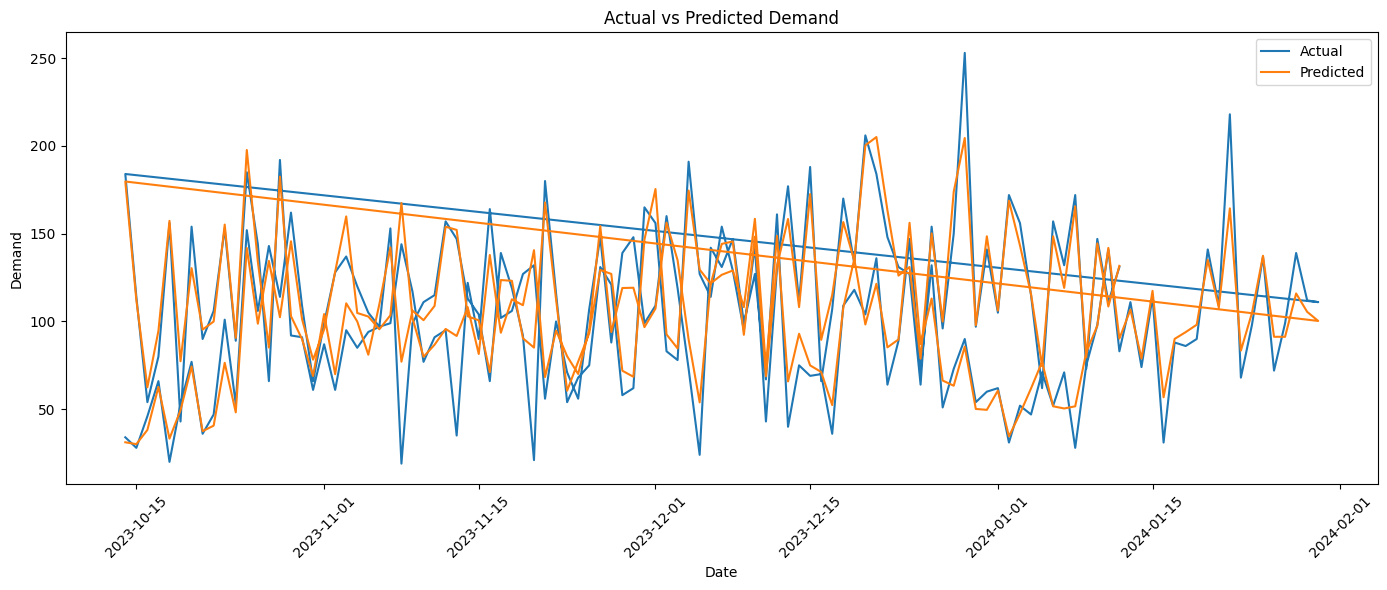

In [0]:
plt.figure(figsize=(14, 6))

plt.plot(test_df["Date"].values[:200],y_test.values[:200],label="Actual")

plt.plot(test_df["Date"].values[:200],y_pred[:200],label="Predicted")

plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("Actual vs Predicted Demand")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

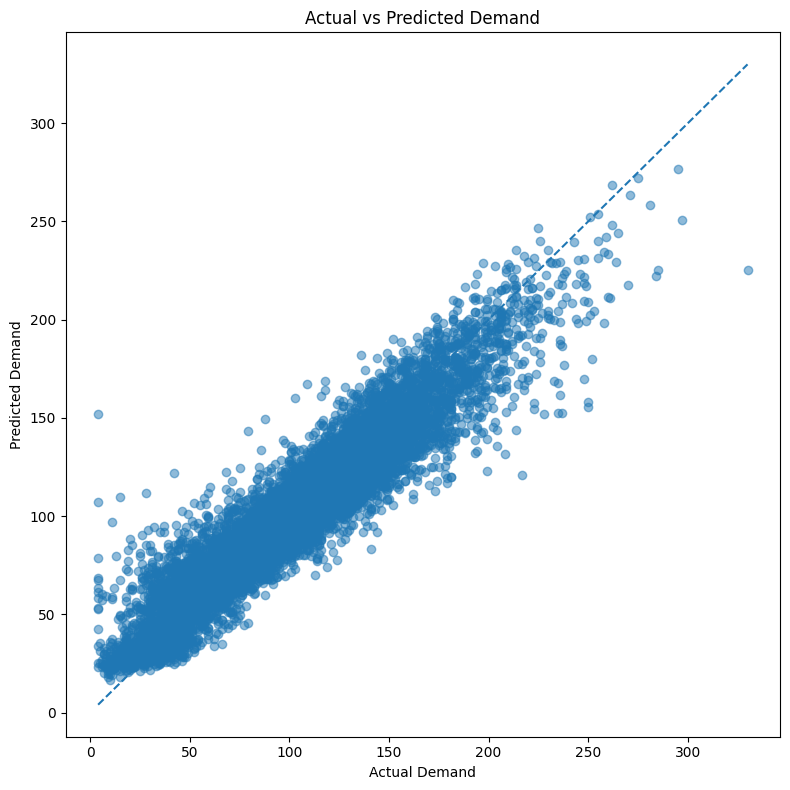

In [0]:
plt.figure(figsize=(8, 8))

plt.scatter(y_test,y_pred, alpha=0.5)

min_value = min(y_test.min(), y_pred.min())

max_value = max(y_test.max(), y_pred.max())

plt.plot([min_value, max_value], [min_value, max_value],linestyle="--")

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")

plt.title("Actual vs Predicted Demand")

plt.tight_layout()
plt.show()

In [0]:
# Residual = Actual - Predicted

residuals = (y_test.values - y_pred)

evaluation_df = test_df[
    [
        "Date",
        "Store ID",
        "Product ID",
        "Category",
        "Region",
        "Demand"
    ]
].copy()

evaluation_df["Predicted"] = y_pred
evaluation_df["Residual"] = residuals

display(evaluation_df.head(20))

Date,Store ID,Product ID,Category,Region,Demand,Predicted,Residual
2023-10-14T00:00:00.000Z,S001,P0001,Electronics,North,34,31.164289852324075,2.8357101476759254
2023-10-15T00:00:00.000Z,S001,P0001,Electronics,North,28,30.09546751262978,-2.0954675126297815
2023-10-16T00:00:00.000Z,S001,P0001,Electronics,North,46,38.19835903280025,7.801640967199752
2023-10-17T00:00:00.000Z,S001,P0001,Electronics,North,66,62.7153292657678,3.2846707342322006
2023-10-18T00:00:00.000Z,S001,P0001,Electronics,North,20,33.255848994695384,-13.255848994695384
2023-10-19T00:00:00.000Z,S001,P0001,Electronics,North,53,49.4161178664845,3.5838821335155018
2023-10-20T00:00:00.000Z,S001,P0001,Electronics,North,77,74.34179816549477,2.6582018345052347
2023-10-21T00:00:00.000Z,S001,P0001,Electronics,North,36,37.48248678336534,-1.4824867833653386
2023-10-22T00:00:00.000Z,S001,P0001,Electronics,North,47,40.6363076970708,6.363692302929202
2023-10-23T00:00:00.000Z,S001,P0001,Electronics,North,101,76.44129072471901,24.55870927528099


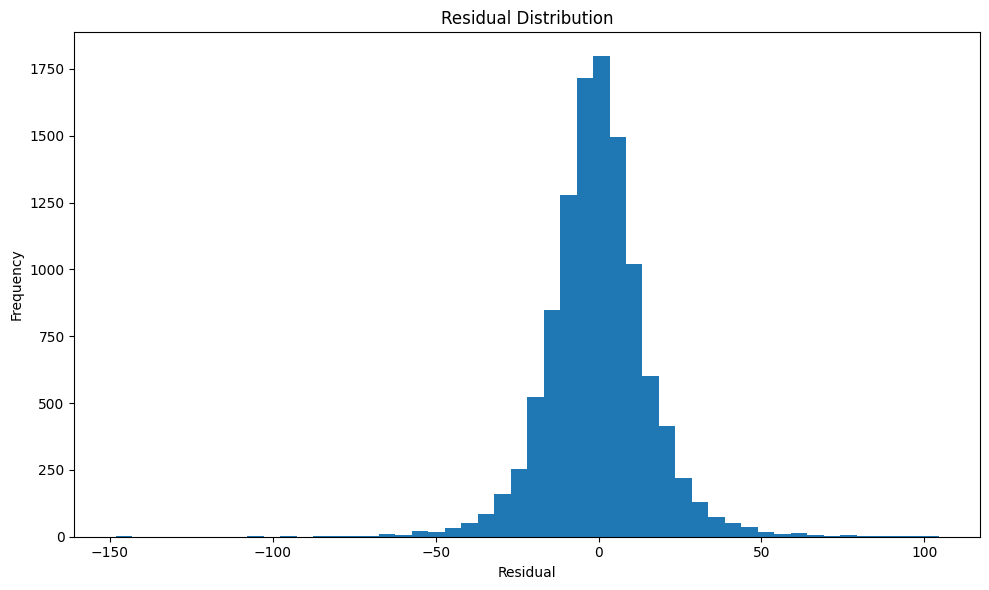

In [0]:
plt.figure(figsize=(10, 6))

plt.hist(residuals,bins=50)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.tight_layout()
plt.show()

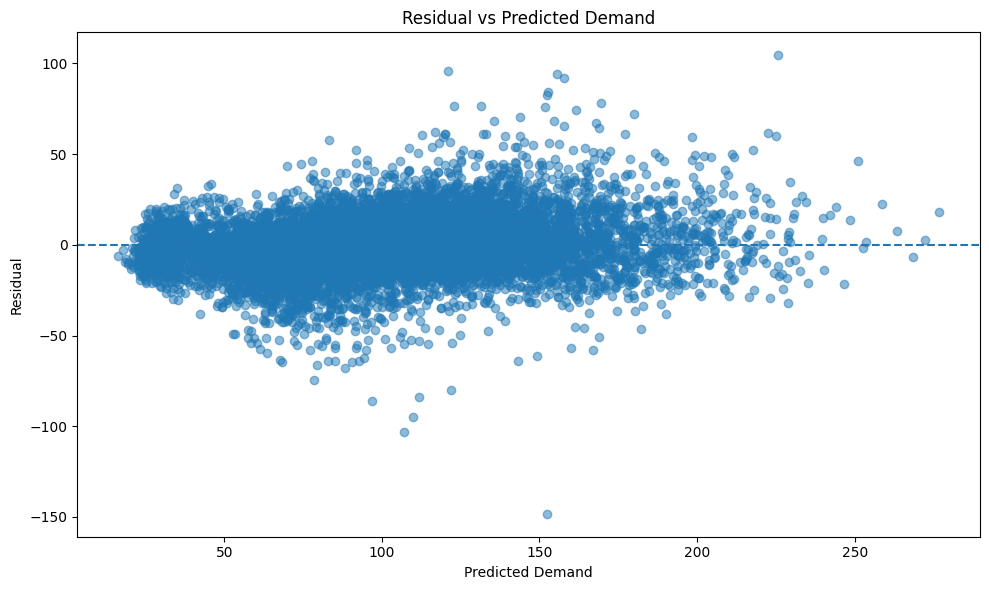

In [0]:
plt.figure(figsize=(10, 6))

plt.scatter(y_pred,residuals,alpha=0.5)

plt.axhline(y=0,linestyle="--")

plt.xlabel("Predicted Demand")
plt.ylabel("Residual")

plt.title("Residual vs Predicted Demand")

plt.tight_layout()
plt.show()

In [0]:
category_evaluation = (
    evaluation_df
    .assign(
        Absolute_Error=lambda x:
        np.abs(
            x["Demand"] - x["Predicted"]
        )
    )
    .groupby("Category")
    .agg(
        Actual_Demand=("Demand", "mean"),
        Predicted_Demand=("Predicted", "mean"),
        MAE=("Absolute_Error", "mean"),
        Count=("Demand", "count")
    )
    .sort_values(
        "MAE",
        ascending=False
    )
)

display(category_evaluation)

/home/spark-d0436f58-16bc-4130-96bc-eb/.ipykernel/75/command-7489250896536030-2573855764:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Category")


Actual_Demand,Predicted_Demand,MAE,Count
112.89977064220183,112.55374408217565,13.171876707452597,4360
85.01179554390563,87.15053938691882,11.825160008591064,1526
117.39850917431193,116.74146228986989,10.979329879033562,1744
95.36162079510703,95.69703287538047,9.855106358554353,1308
71.3710499490316,71.94351698728146,6.999062331112552,1962


In [0]:
region_evaluation = (
    evaluation_df
    .assign(
        Absolute_Error=lambda x:
        np.abs(
            x["Demand"] - x["Predicted"]
        )
    )
    .groupby("Region")
    .agg(
        Actual_Demand=("Demand", "mean"),
        Predicted_Demand=("Predicted", "mean"),
        MAE=("Absolute_Error", "mean"),
        Count=("Demand", "count")
    )
    .sort_values(
        "MAE",
        ascending=False
    )
)

display(region_evaluation)

/home/spark-d0436f58-16bc-4130-96bc-eb/.ipykernel/75/command-7489250896536029-3710493629:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Region")


Actual_Demand,Predicted_Demand,MAE,Count
102.14128440366973,102.78021199304602,11.30016198051207,2180
102.82981651376147,102.96988544314985,11.211379255600797,2180
98.97912844036698,99.0993031061839,11.145858869822165,4360
97.74816513761468,97.72471693230834,10.813790261522502,2180


In [0]:
worst_predictions = (
    evaluation_df
    .assign(
        Absolute_Error=lambda x:
        np.abs(
            x["Demand"] - x["Predicted"]
        )
    )
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
)

display(
    worst_predictions.head(20)
)

Date,Store ID,Product ID,Category,Region,Demand,Predicted,Residual,Absolute_Error
2023-12-05T00:00:00.000Z,S004,P0004,Groceries,West,4,152.24259083411738,-148.24259083411738,148.24259083411738
2023-12-08T00:00:00.000Z,S001,P0009,Clothing,North,330,225.52954365374453,104.47045634625547,104.47045634625547
2023-12-25T00:00:00.000Z,S003,P0010,Groceries,East,4,107.15534695501438,-103.15534695501438,103.15534695501438
2024-01-13T00:00:00.000Z,S003,P0004,Groceries,East,217,121.06551415520696,95.93448584479304,95.93448584479304
2023-12-20T00:00:00.000Z,S003,P0013,Groceries,East,15,109.82368302650185,-94.82368302650185,94.82368302650185
2023-12-09T00:00:00.000Z,S004,P0010,Groceries,West,250,155.69341258672884,94.30658741327116,94.30658741327116
2023-12-19T00:00:00.000Z,S001,P0007,Groceries,North,250,157.89728818994388,92.10271181005612,92.10271181005612
2024-01-16T00:00:00.000Z,S004,P0002,Groceries,West,11,97.00815279430577,-86.00815279430577,86.00815279430577
2023-10-26T00:00:00.000Z,S005,P0015,Groceries,North,237,152.6298188958757,84.3701811041243,84.3701811041243
2023-11-18T00:00:00.000Z,S003,P0002,Groceries,East,28,111.83936726347586,-83.83936726347586,83.83936726347586


In [0]:
best_predictions = (
    evaluation_df
    .assign(
        Absolute_Error=lambda x:
        np.abs(
            x["Demand"] - x["Predicted"]
        )
    )
    .sort_values(
        "Absolute_Error",
        ascending=True
    )
)

display(
    best_predictions.head(20)
)

Date,Store ID,Product ID,Category,Region,Demand,Predicted,Residual,Absolute_Error
2023-12-09T00:00:00.000Z,S003,P0005,Toys,East,89,89.00553244541905,-0.005532445419049736,0.005532445419049736
2023-12-30T00:00:00.000Z,S004,P0014,Furniture,West,36,36.00595033912987,-0.005950339129867643,0.005950339129867643
2024-01-08T00:00:00.000Z,S001,P0016,Groceries,North,76,76.00761456772375,-0.007614567723749133,0.007614567723749133
2023-12-24T00:00:00.000Z,S001,P0015,Toys,North,91,90.99157563930521,0.008424360694789357,0.008424360694789357
2023-12-20T00:00:00.000Z,S005,P0013,Groceries,North,134,134.01027736570322,-0.010277365703217356,0.010277365703217356
2023-11-14T00:00:00.000Z,S005,P0001,Groceries,North,88,88.01375492204582,-0.01375492204581974,0.01375492204581974
2023-11-05T00:00:00.000Z,S005,P0020,Toys,North,88,88.01675364100757,-0.016753641007568376,0.016753641007568376
2023-11-20T00:00:00.000Z,S002,P0020,Furniture,South,66,66.0183186452543,-0.01831864525429694,0.01831864525429694
2023-11-14T00:00:00.000Z,S001,P0013,Toys,North,114,113.97883458530166,0.021165414698344875,0.021165414698344875
2024-01-16T00:00:00.000Z,S001,P0012,Groceries,North,87,86.9785206592944,0.021479340705596428,0.021479340705596428


In [0]:
with mlflow.start_run(
    run_id=run_id
):

    mlflow.log_metrics({
        "test_mae": mae,
        "test_rmse": rmse,
        "test_r2": r2,
        "test_mape": mape,

        "baseline_mae": baseline_mae,
        "baseline_rmse": baseline_rmse,
        "baseline_r2": baseline_r2,
        "baseline_mape": baseline_mape,

        "mae_improvement_pct": mae_improvement,
        "rmse_improvement_pct": rmse_improvement,
        "mape_improvement_pct": mape_improvement
    })

print("Evaluation metrics logged to MLflow.")

Evaluation metrics logged to MLflow.


In [0]:
print("=" * 60)
print("DEMAND FORECASTING - FINAL EVALUATION")
print("=" * 60)

print("\nLightGBM")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

print("\nBaseline")
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")
print(f"MAPE : {baseline_mape:.2f}%")

print("\nImprovement")
print(f"MAE  : {mae_improvement:.2f}%")
print(f"RMSE : {rmse_improvement:.2f}%")
print(f"MAPE : {mape_improvement:.2f}%")

print("=" * 60)

DEMAND FORECASTING - FINAL EVALUATION

LightGBM
MAE  : 11.1234
RMSE : 15.2543
R²   : 0.8835
MAPE : 17.59%

Baseline
MAE  : 39.9376
RMSE : 51.7187
R²   : -0.3390
MAPE : 53.25%

Improvement
MAE  : 72.15%
RMSE : 70.51%
MAPE : 66.98%
